# Probability-orthonormal ReLU emulation diagnostics

This notebook studies the root-factorized ReLU emulators for Legendre
polynomials under $d\rho_L=dx/2$ and Chebyshev polynomials under
$d\rho_C=dx/(\pi\sqrt{1-x^2})$. Exact values use stable recurrences; emulated
values use analytic ReLU multiplication networks.


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from neural_polynomial_emulation import (
    ReLUSquaringNet,
    basis_error_by_degree,
    emulated_chebyshev_basis,
    emulated_legendre_basis,
    exact_chebyshev_basis,
    exact_legendre_basis,
    relative_frobenius_mismatch,
)

torch.set_grad_enabled(False)
FAMILIES = ("legendre", "chebyshev")
FAMILY_APIS = {
    "legendre": {
        "label": "Legendre",
        "exact": exact_legendre_basis,
        "emulated": emulated_legendre_basis,
        "sample": lambda rng, size: rng.uniform(-1.0, 1.0, size=size),
    },
    "chebyshev": {
        "label": "Chebyshev",
        "exact": exact_chebyshev_basis,
        "emulated": emulated_chebyshev_basis,
        "sample": lambda rng, size: np.cos(rng.uniform(0.0, np.pi, size=size)),
    },
}


## Squaring network

On ([-1,1]), the analytic bound is (4^{-L}), where (L) is the number of
sawtooth refinement layers.


In [2]:
x = torch.linspace(-1.0, 1.0, 8193, dtype=torch.float64)
rows = []
for layers in (2, 4, 6, 8, 10, 12):
    net = ReLUSquaringNet(-1.0, 1.0, num_layers=layers)
    error = torch.max(torch.abs(net(x) - x.square())).item()
    rows.append({
        "num_layers": layers,
        "sup_error": error,
        "bound": net.error_bound(),
    })
squaring = pd.DataFrame(rows)
squaring


,num_layers,sup_error,bound
0,2,6.250000e-02,6.250000e-02
1,4,3.906250e-03,3.906250e-03
2,6,2.441406e-04,2.441406e-04
3,8,1.525879e-05,1.525879e-05
4,10,9.536743e-07,9.536743e-07
5,12,5.960464e-08,5.960464e-08


## Degree and depth dependence

The multiplication error propagates through products of root factors.
Increasing depth improves low-degree emulation; conditioning of the
factorization eventually dominates.


In [3]:
rows = []
for family in FAMILIES:
    for layers in (4, 8, 12, 16):
        family_errors = basis_error_by_degree(
            16,
            family=family,
            product="relu",
            num_layers=layers,
            grid_size=2001,
        )
        rows.extend(
            {
                "family": family,
                "degree": degree,
                "num_layers": layers,
                "sup_error": error,
            }
            for degree, error in enumerate(family_errors)
        )
errors = pd.DataFrame(rows)
errors.pivot(index="degree", columns=("family", "num_layers"), values="sup_error")


family          legendre                                            \
num_layers            4             8             12            16   
degree                                                               
0           0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
1           0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
2           7.247565e-02  2.067182e-04  9.362618e-07  4.299740e-09   
3           7.136333e-01  3.070369e-03  1.276717e-05  4.711650e-08   
4           6.134571e+00  2.438677e-02  1.068409e-04  4.257706e-07   
5           4.167792e+01  2.007284e-01  8.336835e-04  3.332306e-06   
6           2.262763e+02  1.759961e+00  6.251628e-03  2.697035e-05   
7           3.334125e+03  1.275936e+01  4.807105e-02  2.082855e-04   
8           2.520165e+04  9.352558e+01  3.939169e-01  1.671920e-03   
9           2.091098e+05  8.155854e+02  3.474269e+00  1.301563e-02   
10          1.726844e+06  5.516059e+03  2.461365e+01  1.077492e-01   
11          2.598062e+09  4.028957e+04  1.928139e+02  8.114123e-01   
12          2.076792e+10  4.192087e+05  1.632362e+03  6.254343e+00   
13          1.660204e+11  3.331109e+06  1.304638e+04  5.040166e+01   
14          1.327316e+12  2.767174e+07  1.034279e+05  3.946931e+02   
15          1.061263e+13  2.309587e+08  9.700474e+05  3.429258e+03   
16          8.485955e+13  1.809118e+09  6.667148e+06  2.630864e+04   

family         chebyshev                                            
num_layers            4             8             12            16  
degree                                                              
0           0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  
1           2.220446e-16  2.220446e-16  2.220446e-16  2.220446e-16  
2           4.939799e-02  2.174660e-04  6.904425e-07  3.228362e-09  
3           7.015928e-01  2.863994e-03  1.170200e-05  4.005477e-08  
4           4.933768e+00  2.320044e-02  8.317924e-05  4.303110e-07  
5           3.367857e+01  1.715630e-01  7.168604e-04  2.810330e-06  
6           1.785232e+02  1.505097e+00  6.129590e-03  2.286055e-05  
7           2.901673e+03  1.122455e+01  4.596104e-02  1.774126e-04  
8           2.184299e+04  8.302511e+01  3.426405e-01  1.539983e-03  
9           1.845103e+05  7.241254e+02  3.144086e+00  1.123285e-02  
10          1.497832e+06  5.188870e+03  2.142889e+01  8.915789e-02  
11          2.277583e+09  3.767775e+04  1.708382e+02  6.727556e-01  
12          1.822200e+10  3.669555e+05  1.435956e+03  5.652725e+00  
13          1.457760e+11  2.934671e+06  1.137987e+04  4.411082e+01  
14          1.166208e+12  2.424749e+07  9.183618e+04  3.487455e+02  
15          9.329666e+12  1.977139e+08  8.643590e+05  3.069090e+03  
16          7.463732e+13  1.604918e+09  5.920965e+06  2.316722e+04

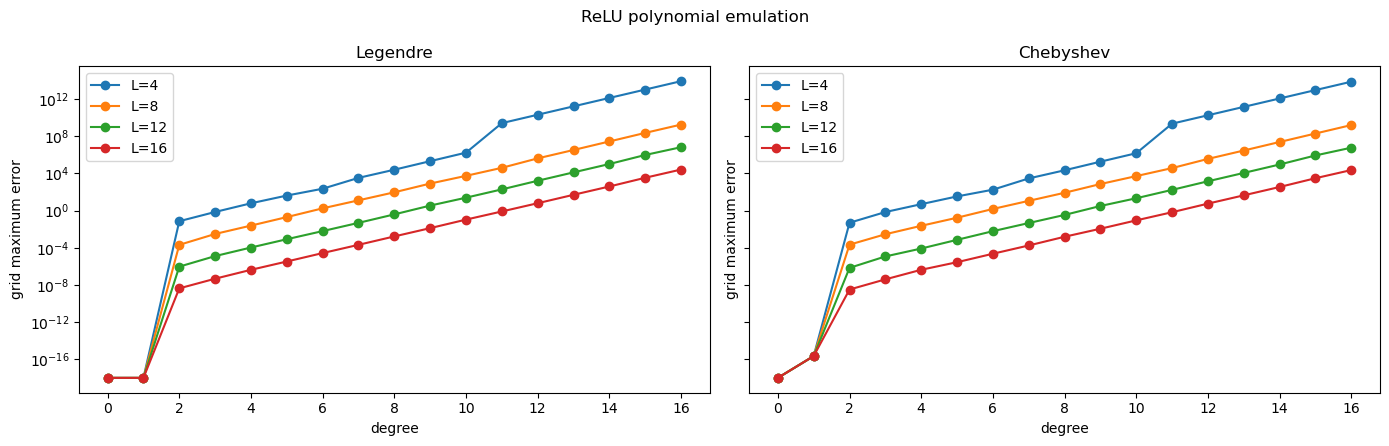

In [4]:
fig, axes = plt.subplots(1, len(FAMILIES), figsize=(14, 4.5), sharey=True)
for ax, family in zip(axes, FAMILIES):
    family_errors = errors[errors["family"] == family]
    for layers, group in family_errors.groupby("num_layers"):
        ax.semilogy(
            group["degree"],
            np.maximum(group["sup_error"], 1e-18),
            marker="o",
            label=f"L={layers}",
        )
    ax.set(
        xlabel="degree",
        ylabel="grid maximum error",
        title=FAMILY_APIS[family]["label"],
    )
    ax.legend()
fig.suptitle("ReLU polynomial emulation")
fig.tight_layout()
plt.show()


## Measurement-matrix mismatch

The Frobenius mismatch measures the perturbation seen by a downstream
coefficient-recovery method. Each family is sampled from its defining
probability measure.


In [5]:
rng = np.random.default_rng(31415)
rows = []
for family in FAMILIES:
    api = FAMILY_APIS[family]
    samples = api["sample"](rng, 512)
    for max_degree in (4, 8, 12, 16):
        exact = api["exact"](samples, max_degree)
        for layers in (8, 12, 16):
            approximate = api["emulated"](
                samples,
                max_degree,
                product="relu",
                num_layers=layers,
            ).numpy()
            rows.append({
                "family": family,
                "max_degree": max_degree,
                "num_layers": layers,
                "relative_frobenius_mismatch": relative_frobenius_mismatch(
                    exact, approximate
                ),
            })
mismatch = pd.DataFrame(rows)
mismatch.pivot(
    index="max_degree",
    columns=("family", "num_layers"),
    values="relative_frobenius_mismatch",
)


family          legendre                                  chebyshev  \
num_layers            8              12            16            8    
max_degree                                                            
4           4.997138e-03       0.000019  7.511838e-08  4.530642e-03   
8           1.629424e+01       0.062829  2.261200e-04  1.200155e+01   
12          5.716508e+04     216.682840  8.820707e-01  4.962908e+04   
16          2.133822e+08  616795.031276  3.029236e+03  1.861960e+08   

family                                   
num_layers             12            16  
max_degree                               
4                0.000017  6.543714e-08  
8                0.052420  1.980596e-04  
12             147.037514  7.841059e-01  
16          611248.870199  2.081553e+03